<a href="https://colab.research.google.com/github/Gabriel-Menezes-Morais/Blurry-Image-Recovery/blob/main/blurry_image_recovery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#This homework objective is to avaliate computacional efficiency between two images algorithms

In [46]:
import matplotlib.pyplot as plt
import numpy as np
import scipy
import matplotlib.pyplot as plt
from scipy.linalg import circulant
import time

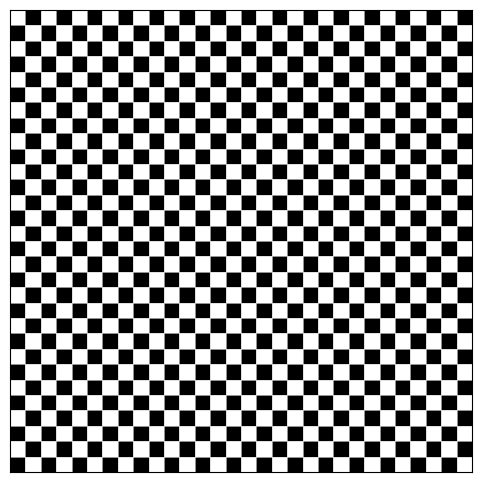

In [47]:
# Firstly, we start building a 30x30 image of a game table, with a xadrez pattern

pixel_art = np.array([
    [(i + j) % 2 for j in range(30)] for i in range(30)
])

cmap = plt.cm.colors.ListedColormap(['white', 'black'])
bounds = [0, 1] # Limites para as cores
norm = plt.cm.colors.BoundaryNorm(bounds, cmap.N)

# Cria o gráfico
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(pixel_art, cmap=cmap, norm=norm, interpolation='nearest')

# Remove os ticks e rótulos dos eixos
ax.set_xticks([])
ax.set_yticks([])

# Adiciona uma grade para separar claramente os pixels
ax.set_xticks(np.arange(-.5, pixel_art.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-.5, pixel_art.shape[0], 1), minor=True)
ax.grid(which="minor", color="lightgray", linestyle='-', linewidth=0.5)
ax.tick_params(which="minor", size=0)

plt.show()

In [48]:
# Converter essa matriz geométrica em um vetor unidimensional x contendo 900 elementos (n=900)

x = pixel_art.flatten()
print(x)

[0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 1 0 1 0 1 0 1
 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1
 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1
 0 1 0 1 0 1 0 1 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1
 0 1 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 0 1 0 1 0
 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 1 0 1 0 1 0 1 0 1 0 1 0
 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0
 1 0 1 0 1 0 1 0 1 0 1 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0
 1 0 1 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 1 0 1
 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 0 1 0 1 0 1 0 1 0 1
 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1
 0 1 0 1 0 1 0 1 0 1 0 1 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1
 0 1 0 1 0 1 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 0
 1 0 1 0 1 0 1 0 1 0 1 0 

# Now, we will simulate the image blur effect

In [49]:
# Building the c array to use at scipy.linalg.circulant

c = np.zeros(900)

w0 = 0.5
w1 = 0.2
c[0] = w0
c[1] = w1
c[-1] = w1

print(c)

[0.5 0.2 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. 

In [50]:
# degradation matrix

A = scipy.linalg.circulant(c)
print(A)

[[0.5 0.2 0.  ... 0.  0.  0.2]
 [0.2 0.5 0.2 ... 0.  0.  0. ]
 [0.  0.2 0.5 ... 0.  0.  0. ]
 ...
 [0.  0.  0.  ... 0.5 0.2 0. ]
 [0.  0.  0.  ... 0.2 0.5 0.2]
 [0.2 0.  0.  ... 0.  0.2 0.5]]


In [51]:
# pertubation

n = 0.001 * np.random.randn(900)
print(n)

[ 3.68673309e-04 -3.93338812e-04  2.87448229e-05  1.27845186e-03
  1.91099068e-04  4.64365482e-05 -1.35985614e-03  7.46253566e-04
  6.45484181e-04  2.16325472e-03 -3.07778235e-04  2.19150328e-04
  2.49383684e-04  1.57745328e-03 -9.52955324e-05  2.79021526e-04
  6.07896510e-04  1.86609123e-04 -4.46433615e-04  1.94089993e-04
  1.07363175e-03 -1.02651530e-03  1.32969674e-04 -7.00120815e-04
  1.19504663e-03 -1.52318690e-03 -5.58921847e-04  3.77211875e-04
  1.56552403e-03 -6.57502611e-05 -5.55199527e-04  1.88115707e-03
 -1.44801390e-03 -2.19880596e-03  4.40014450e-04 -5.02054224e-04
 -1.02123282e-03  7.08356447e-04  2.43800714e-04 -5.64078631e-04
 -1.28030440e-03  8.72457328e-04  6.50201178e-04 -9.91758638e-05
  1.84663700e-03 -1.07008477e-03 -1.52552517e-03 -6.91908070e-04
 -4.55860164e-05  2.43339449e-04 -2.41236058e-04  3.52055397e-04
 -1.25153942e-03  1.44376460e-03 -8.21511784e-05  1.11729583e-03
  3.42725346e-04  4.56753219e-04  5.69767280e-04  4.47708560e-04
  6.42722760e-04  1.32915

In [52]:
# blur array

b = A @ x + n
print(b)

[0.20036867 0.49960666 0.40002874 0.50127845 0.4001911  0.50004644
 0.39864014 0.50074625 0.40064548 0.50216325 0.39969222 0.50021915
 0.40024938 0.50157745 0.3999047  0.50027902 0.4006079  0.50018661
 0.39955357 0.50019409 0.40107363 0.49897348 0.40013297 0.49929988
 0.40119505 0.49847681 0.39944108 0.50037721 0.40156552 0.69993425
 0.6994448  0.40188116 0.49855199 0.39780119 0.50044001 0.39949795
 0.49897877 0.40070836 0.5002438  0.39943592 0.4987197  0.40087246
 0.5006502  0.39990082 0.50184664 0.39892992 0.49847447 0.39930809
 0.49995441 0.40024334 0.49975876 0.40035206 0.49874846 0.40144376
 0.49991785 0.4011173  0.50034273 0.40045675 0.50056977 0.20044771
 0.20064272 0.50132915 0.40019652 0.500709   0.39991026 0.50144012
 0.39932361 0.50180094 0.39995984 0.49856922 0.4001281  0.49931895
 0.40084064 0.49934738 0.39955382 0.49811046 0.39954769 0.49757612
 0.3984161  0.50076041 0.4007858  0.50042546 0.39903302 0.49995229
 0.3999964  0.49884164 0.4015034  0.50087736 0.39977904 0.7000

In [53]:
# transform b in to a matrix

M = b.reshape(30, 30)

print(M)

[[0.20036867 0.49960666 0.40002874 0.50127845 0.4001911  0.50004644
  0.39864014 0.50074625 0.40064548 0.50216325 0.39969222 0.50021915
  0.40024938 0.50157745 0.3999047  0.50027902 0.4006079  0.50018661
  0.39955357 0.50019409 0.40107363 0.49897348 0.40013297 0.49929988
  0.40119505 0.49847681 0.39944108 0.50037721 0.40156552 0.69993425]
 [0.6994448  0.40188116 0.49855199 0.39780119 0.50044001 0.39949795
  0.49897877 0.40070836 0.5002438  0.39943592 0.4987197  0.40087246
  0.5006502  0.39990082 0.50184664 0.39892992 0.49847447 0.39930809
  0.49995441 0.40024334 0.49975876 0.40035206 0.49874846 0.40144376
  0.49991785 0.4011173  0.50034273 0.40045675 0.50056977 0.20044771]
 [0.20064272 0.50132915 0.40019652 0.500709   0.39991026 0.50144012
  0.39932361 0.50180094 0.39995984 0.49856922 0.4001281  0.49931895
  0.40084064 0.49934738 0.39955382 0.49811046 0.39954769 0.49757612
  0.3984161  0.50076041 0.4007858  0.50042546 0.39903302 0.49995229
  0.3999964  0.49884164 0.4015034  0.50087736 

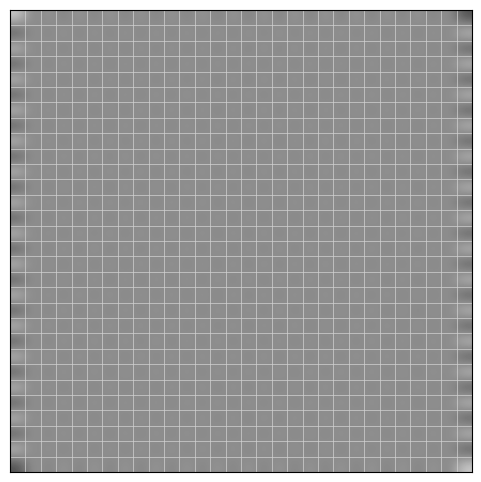

In [54]:
# Cria o gráfico
fig, ax = plt.subplots(figsize=(6, 6))
# Usa o colormap 'binary' (0 = branco, 1 = preto)
# vmin e vmax garantem que a escala fique travada entre 0 e 1
ax.imshow(M, cmap='binary', vmin=0, vmax=1, interpolation='bicubic')
# Remove os ticks e rótulos dos eixos
ax.set_xticks([])
ax.set_yticks([])

# Adiciona uma grade para separar claramente os pixels
ax.set_xticks(np.arange(-.5, M.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-.5, M.shape[0], 1), minor=True)
ax.grid(which="minor", color="lightgray", linestyle='-', linewidth=0.5)
ax.tick_params(which="minor", size=0)

plt.show()

# Now, will be built the algorithms logic

In [55]:
%%writefile metodos_reconstrucao.py
import numpy as np

# =================================================================
# 1. MÉTODOS DIRETOS
# =================================================================

def decomposicao_lu(A):
    """
    Realiza a fatoração LU clássica de uma matriz A.
    Retorna as matrizes L e U.
    """
    n = A.shape[0]
    L = np.eye(n)
    U = A.copy().astype(float)

    for k in range(n-1):
      for i in range(k+1, n):
        if U[k, k] == 0:
            raise ValueError("Pivô nulo encontrado. Implemente pivoteamento!")

        L[i, k] = U[i, k] / U[k, k]
        U[i, k:n] = U[i, k:n] - L[i, k] * U[k, k:n]

    return L, U

def decomposicao_cholesky(A):
    """
    Realiza a fatoração de Cholesky de uma matriz simétrica e positiva definida A.
    Retorna a matriz triangular inferior G (onde A = G @ G.T).
    """
    n = A.shape[0]
    G = np.zeros_like(A, dtype=float)

    for i in range(n):
        for j in range(i+1):
            if i == j:  # Diagonal
                soma = np.sum(G[i, :j] ** 2)
                G[i, j] = np.sqrt(A[i, i] - soma)
            else:  # Fora da diagonal
                soma = np.sum(G[i, :j] * G[j, :j])
                G[i, j] = (A[i, j] - soma) / G[j, j]
    return G

def resolver_triangular_inferior(L, b):
    """
    Resolve o sistema L @ y = b por substituição sucessiva (pra frente).
    """
    n = len(b)
    y = np.zeros(n)

    for i in range(n):
        soma = np.dot(L[i, :i], y[:i])
        y[i] = (b[i] - soma) / L[i, i]
    return y

def resolver_triangular_superior(U, y):
    """
    Resolve o sistema U @ x = y por substituição retroativa (pra trás).
    """
    n = len(y)
    x = np.zeros(n)

    for i in range(n-1, -1, -1):
        soma = np.dot(U[i, i+1:n], x[i+1:n])
        x[i] = (y[i] - soma) / U[i, i]
    return x

# =================================================================
# 2. MÉTODOS ITERATIVOS
# =================================================================

def jacobi_customizado(A, b, x0, max_iter, tol=None):
    """
    Resolve o sistema A @ x = b pelo método de Gauss-Jacobi.
    Retorna o vetor aproximado x e a lista 'historico_erro' contendo a norma do erro.
    """
    n = len(b)
    x = x0.copy().astype(float)
    x_novo = np.zeros_like(x)
    historico_erro = []

    for k in range(max_iter):

        for i in range(n):
            soma = np.dot(A[i, :i], x[:i]) + np.dot(A[i, i+1:], x[i+1:])
            x_novo[i] = (b[i] - soma) / A[i, i]
        norma_erro = np.linalg.norm(x_novo - x)
        historico_erro.append(norma_erro)

        if tol is not None and norma_erro < tol:
            return x_novo, historico_erro

        x = x_novo.copy()

    return x, historico_erro

def gauss_seidel_customizado(A, b, x0, max_iter, tol=None):
    """
    Resolve o sistema A @ x = b pelo método de Gauss-Seidel.
    Retorna o vetor aproximado x e a lista 'historico_erro' contendo a norma do erro.
    """
    n = len(b)
    x = x0.copy().astype(float)
    historico_erro = []

    for k in range(max_iter):
        x_antigo = x.copy()

        for i in range(n):
            soma = np.dot(A[i, :i], x[:i]) + np.dot(A[i, i+1:], x[i+1:])
            x[i] = (b[i] - soma) / A[i, i]

        norma_erro = np.linalg.norm(x - x_antigo)
        historico_erro.append(norma_erro)

        if tol is not None and norma_erro < tol:
            return x, historico_erro

    return x, historico_erro

Overwriting metodos_reconstrucao.py


INICIANDO LABORATÓRIO DE PROCESSAMENTO NUMÉRICO DE IMAGENS
Dimensão do sistema linear: n = 900 (Malha 30x30)

--- TESTE 1: Executando Cenário Padrão (w0 = 0.6, w1 = 0.2) ---
Executando Fatoração LU Manual...
Tempo LU Direto: 2.4980 segundos
Executando Multiplicação de Matrizes e Fatoração de Cholesky...
Tempo Cholesky Completo: 6.2047 segundos
Executando métodos iterativos de Jacobi e Gauss-Seidel...


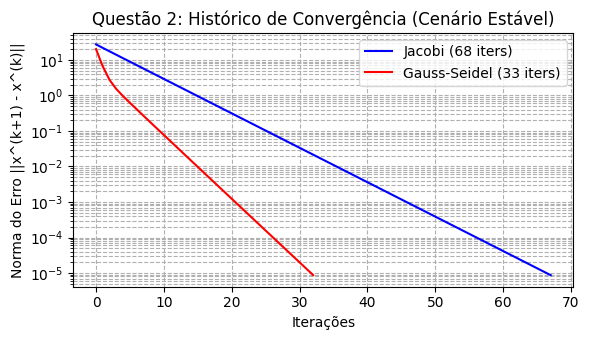


--- TESTE 2: Executando Cenário Instável (w0 = 0.2, w1 = 0.4) ---
Avaliando divergência nos métodos iterativos...


/content/metodos_reconstrucao.py:111: RuntimeWarning: overflow encountered in scalar divide
  x_antigo = x.copy()


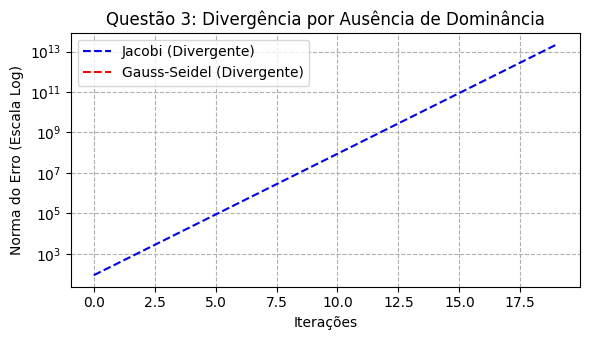


Gerando painel visual comparativo de reconstrução de imagens...


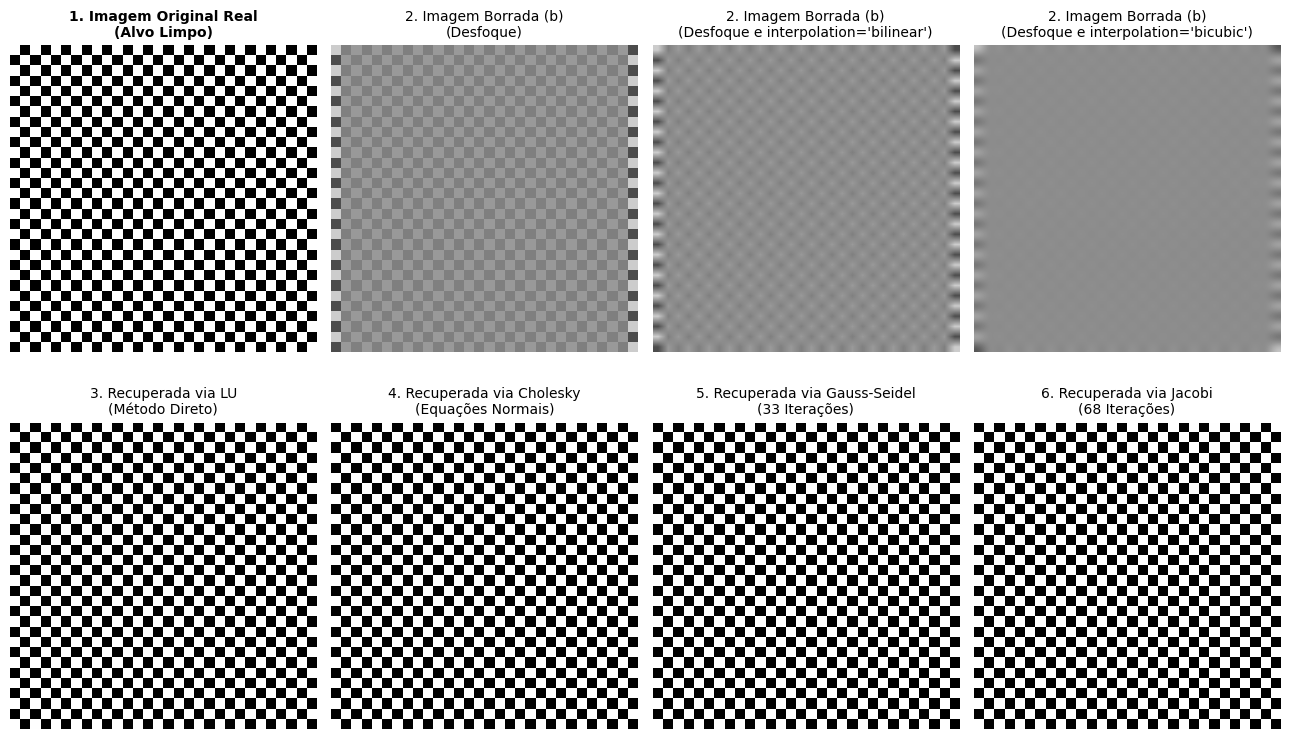


 Fim da execução do script principal!


In [56]:
import importlib

# Importa o arquivo criado na célula anterior
import metodos_reconstrucao as mr
importlib.reload(mr)

# =================================================================
# CONFIGURAÇÃO DO EXPERIMENTO (TABULEIRO 30x30 -> n = 900)
# =================================================================
n_side = 30
n_total = n_side**2
np.random.seed(42)

x0 = np.zeros(n_total)

print("=================================================================")
print("INICIANDO LABORATÓRIO DE PROCESSAMENTO NUMÉRICO DE IMAGENS")
print(f"Dimensão do sistema linear: n = {n_total} (Malha {n_side}x{n_side})")
print("=================================================================\n")

# =================================================================
# TESTE 1: CENÁRIO PADRÃO
# =================================================================
print("--- TESTE 1: Executando Cenário Padrão (w0 = 0.6, w1 = 0.2) ---")

# Execução: Fatoração LU Manual
print("Executando Fatoração LU Manual...")
t0 = time.time()
try:
    L, U = mr.decomposicao_lu(A)
    y_lu = mr.resolver_triangular_inferior(L, b)
    x_lu_resultado = mr.resolver_triangular_superior(U, y_lu)
    t_lu = time.time() - t0
    print(f"Tempo LU Direto: {t_lu:.4f} segundos")
except Exception as e:
    x_lu_resultado = None
    print("LU não executado ou incompleto.")

# Execução: Cholesky com Multiplicação Estruturada de Linha x Coluna
print("Executando Multiplicação de Matrizes e Fatoração de Cholesky...")
t0 = time.time()
try:
    ATA_otimizado = np.zeros((n_total, n_total))
    AT = A.T

    # Multiplicação estruturada linha por coluna
    for i in range(n_total):
        for j in range(n_total):
            ATA_otimizado[i, j] = np.dot(AT[i, :], A[:, j])

    ATb_otimizado = np.zeros(n_total)
    for i in range(n_total):
        ATb_otimizado[i] = np.dot(AT[i, :], b)

    G = mr.decomposicao_cholesky(ATA_otimizado)
    y_cho = mr.resolver_triangular_inferior(G, ATb_otimizado)
    x_cho_resultado = mr.resolver_triangular_superior(G.T, y_cho)
    t_cho = time.time() - t0
    print(f"Tempo Cholesky Completo: {t_cho:.4f} segundos")
except Exception as e:
    x_cho_resultado = None
    print("Cholesky não executado ou incompleto.")

# Execução: Métodos Iterativos no Cenário Estável
print("Executando métodos iterativos de Jacobi e Gauss-Seidel...")
try:
    x_jacobi_res, erro_jacobi = mr.jacobi_customizado(A, b, x0, max_iter=200, tol=1e-5)
    x_gs_res, erro_gs = mr.gauss_seidel_customizado(A, b, x0, max_iter=200, tol=1e-5)

    # PLOT 1: Histórico de Convergência (Cenário Estável)
    plt.figure(figsize=(6, 3.5))
    plt.plot(erro_jacobi, label=f'Jacobi ({len(erro_jacobi)} iters)', color='blue', linewidth=1.5)
    plt.plot(erro_gs, label=f'Gauss-Seidel ({len(erro_gs)} iters)', color='red', linewidth=1.5)
    plt.yscale('log')
    plt.title('Questão 2: Histórico de Convergência (Cenário Estável)')
    plt.xlabel('Iterações')
    plt.ylabel('Norma do Erro ||x^(k+1) - x^(k)||')
    plt.grid(True, which="both", ls="--")
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    erro_gs = []
    print("Erro ao rodar os métodos iterativos do Cenário Padrão.")

# =================================================================
# TESTE 2: CENÁRIO INSTÁVEL
# =================================================================
print("\n--- TESTE 2: Executando Cenário Instável (w0 = 0.2, w1 = 0.4) ---")
w0_sd, w1_sd = 0.2, 0.4

c_sd = np.zeros(n_total)
c_sd[0], c_sd[1], c_sd[-1] = w0_sd, w1_sd, w1_sd
A_sd = circulant(c_sd)
b_sd = A_sd @ x + 0.001 * np.random.randn(n_total)

print("Avaliando divergência nos métodos iterativos...")
try:
    _, erro_jacobi_sd = mr.jacobi_customizado(A_sd, b_sd, x0, max_iter=20, tol=1e-5)
    _, erro_gs_sd = mr.gauss_seidel_customizado(A_sd, b_sd, x0, max_iter=20, tol=1e-5)

    # PLOT 2: Gráfico de Divergência
    plt.figure(figsize=(6, 3.5))
    plt.plot(erro_jacobi_sd, label='Jacobi (Divergente)', color='blue', linestyle='--')
    plt.plot(erro_gs_sd, label='Gauss-Seidel (Divergente)', color='red', linestyle='--')
    plt.yscale('log')
    plt.title('Questão 3: Divergência por Ausência de Dominância')
    plt.xlabel('Iterações')
    plt.ylabel('Norma do Erro (Escala Log)')
    plt.grid(True, which="both", ls="--")
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Erro ao rodar os métodos iterativos do Cenário Instável.")

# =================================================================
# PAINEL VISUAL FINAL: COMPARAÇÃO DAS RECONSTRUÇÕES
# =================================================================
print("\nGerando painel visual comparativo de reconstrução de imagens...")
fig, axes = plt.subplots(2, 4, figsize=(13, 8))

# Estado Original e Degradado (Linha Superior)
axes[0, 0].imshow(pixel_art, cmap='binary', vmin=0, vmax=1, interpolation='nearest')
axes[0, 0].set_title("1. Imagem Original Real\n(Alvo Limpo)", fontsize=10, fontweight='bold')

axes[0, 1].imshow(b.reshape(n_side, n_side), cmap='binary', vmin=0, vmax=1, interpolation='nearest')
axes[0, 1].set_title("2. Imagem Borrada (b)\n(Desfoque)", fontsize=10)

axes[0, 2].imshow(b.reshape(n_side, n_side), cmap='binary', vmin=0, vmax=1, interpolation='bilinear')
axes[0, 2].set_title("2. Imagem Borrada (b)\n(Desfoque e interpolation='bilinear')", fontsize=10)

axes[0, 3].imshow(b.reshape(n_side, n_side), cmap='binary', vmin=0, vmax=1, interpolation='bicubic')
axes[0, 3].set_title("2. Imagem Borrada (b)\n(Desfoque e interpolation='bicubic')", fontsize=10)


# Resultados Alcançados (Linha Inferior)
if x_lu_resultado is not None: #M, cmap='binary', vmin=0, vmax=1, interpolation='bicubic'
    axes[1, 0].imshow(x_lu_resultado.reshape(n_side, n_side), cmap='gray', vmin=0, vmax=1)
    axes[1, 0].set_title("3. Recuperada via LU\n(Método Direto)", fontsize=10)
else:
    axes[1, 0].text(0.5, 0.5, 'Incompleto:\nFatoração LU', ha='center', va='center', color='red')

if x_cho_resultado is not None:
    axes[1, 1].imshow(x_cho_resultado.reshape(n_side, n_side), cmap='gray', vmin=0, vmax=1)
    axes[1, 1].set_title("4. Recuperada via Cholesky\n(Equações Normais)", fontsize=10)
else:
    axes[1, 1].text(0.5, 0.5, 'Incompleto:\nCholesky', ha='center', va='center', color='red')

if 'x_gs_res' in locals():
    axes[1, 2].imshow(x_gs_res.reshape(n_side, n_side), cmap='gray', vmin=0, vmax=1)
    axes[1, 2].set_title(f"5. Recuperada via Gauss-Seidel\n({len(erro_gs)} Iterações)", fontsize=10)
else:
    axes[1, 2].text(0.5, 0.5, 'Incompleto:\nGauss-Seidel', ha='center', va='center', color='red')

if 'x_jacobi_res' in locals():
    axes[1, 3].imshow(x_jacobi_res.reshape(n_side, n_side), cmap='gray', vmin=0, vmax=1)
    axes[1, 3].set_title(f"6. Recuperada via Jacobi\n({len(erro_jacobi)} Iterações)", fontsize=10)
else:
    axes[1, 3].text(0.5, 0.5, 'Incompleto:\nJacobi', ha='center', va='center', color='red')

# Ajusta os espaçamentos entre subplots

for row in axes:
    for ax in row:
        if ax.axison:
            ax.axis('off')

plt.tight_layout()
plt.show()

print("\n Fim da execução do script principal!")